FIRST 5 ROWS
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN 

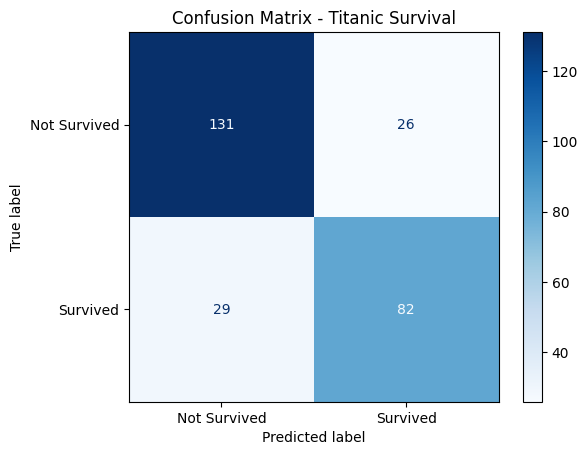


PREDICTED TABLE
     Pclass  Sex        Age     Fare  Embarked  Actual_Survival  \
709       3    1  29.699118  15.2458         0                1   
439       2    1  31.000000  10.5000         2                0   
840       3    1  20.000000   7.9250         2                0   
720       2    0   6.000000  33.0000         2                1   
39        3    0  14.000000  11.2417         0                1   
290       1    0  26.000000  78.8500         2                1   
300       3    0  29.699118   7.7500         1                1   
333       3    1  16.000000  18.0000         2                0   
208       3    0  16.000000   7.7500         1                1   
136       1    0  19.000000  26.2833         2                1   
137       1    1  37.000000  53.1000         2                0   
696       3    1  44.000000   8.0500         2                0   
485       3    0  29.699118  25.4667         2                0   
244       3    1  30.000000   7.2250         

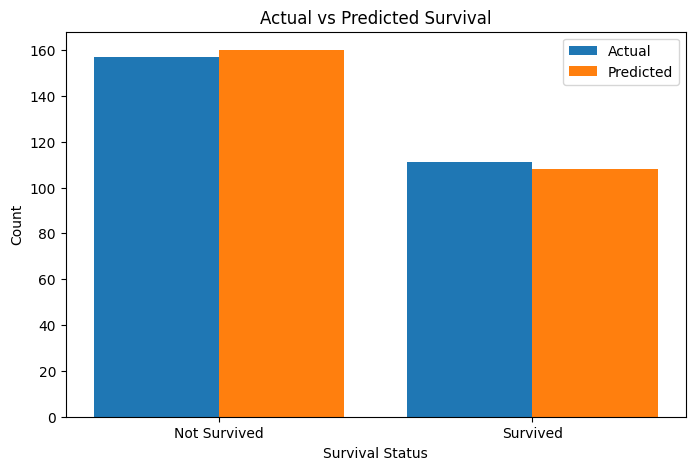

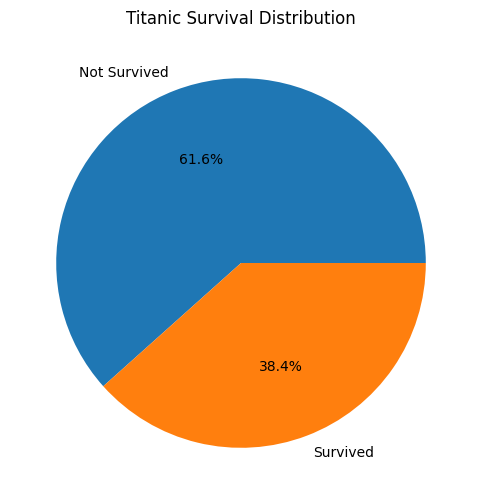


EXTERNAL PREDICTION
Passenger Not Survived


In [1]:
# ============================================
# LOGISTIC REGRESSION - TITANIC DATASET
# MACHINE LEARNING WITH CHARTS
# ============================================

# IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv("titanic.csv")

# ============================================
# DISPLAY DATASET
# ============================================

print("FIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nMISSING VALUES")
print(df.isnull().sum())

# ============================================
# PREPROCESSING
# ============================================

# Fill missing Age values
df["Age"] = df["Age"].fillna(df["Age"].mean())

# Fill missing Embarked values
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Convert categorical columns into numbers
le = LabelEncoder()

df["Sex"] = le.fit_transform(df["Sex"])

df["Embarked"] = le.fit_transform(df["Embarked"])

# ============================================
# SELECT FEATURES AND TARGET
# ============================================

X = df[[
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked"
]]

y = df["Survived"]

# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("\nTRAIN DATA:", X_train.shape)
print("TEST DATA:", X_test.shape)

# ============================================
# CREATE MODEL
# ============================================

model = LogisticRegression()

# ============================================
# TRAIN MODEL
# ============================================

model.fit(X_train, y_train)

# ============================================
# PREDICTION
# ============================================

y_pred = model.predict(X_test)

# ============================================
# ACCURACY
# ============================================

accuracy = accuracy_score(y_test, y_pred)

print("\nACCURACY SCORE")
print(accuracy)

# ============================================
# CLASSIFICATION REPORT
# ============================================

print("\nCLASSIFICATION REPORT")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Survived", "Survived"]
    )
)

# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Survived", "Survived"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Titanic Survival")

plt.show()

# ============================================
# PREDICTED TABLE
# ============================================

predicted_table = X_test.copy()

predicted_table["Actual_Survival"] = y_test.values

predicted_table["Predicted_Survival"] = y_pred

print("\nPREDICTED TABLE")

print(predicted_table.head(20))

# ============================================
# SAVE PREDICTED TABLE
# ============================================

predicted_table.to_csv("titanic_predicted_output.csv", index=False)

print("\nPredicted table saved successfully!")

# ============================================
# BAR CHART
# ============================================

actual_counts = predicted_table["Actual_Survival"].value_counts()

predicted_counts = predicted_table["Predicted_Survival"].value_counts()

labels = ["Not Survived", "Survived"]

x = range(len(labels))

plt.figure(figsize=(8,5))

plt.bar(x, actual_counts.sort_index(), width=0.4, label="Actual")

plt.bar(
    [i + 0.4 for i in x],
    predicted_counts.sort_index(),
    width=0.4,
    label="Predicted"
)

plt.xticks([i + 0.2 for i in x], labels)

plt.xlabel("Survival Status")

plt.ylabel("Count")

plt.title("Actual vs Predicted Survival")

plt.legend()

plt.show()

# ============================================
# PIE CHART
# ============================================

survival_counts = df["Survived"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    survival_counts,
    labels=["Not Survived", "Survived"],
    autopct='%1.1f%%'
)

plt.title("Titanic Survival Distribution")

plt.show()

# ============================================
# EXTERNAL PREDICTION
# ============================================

# Example:
# Pclass = 1
# Sex = male(1)
# Age = 25
# Fare = 100
# Embarked = S(2)

new_data = [[1, 1, 25, 100, 2]]

new_df = pd.DataFrame(
    new_data,
    columns=X.columns
)

result = model.predict(new_df)[0]

print("\nEXTERNAL PREDICTION")

if result == 1:
    print("Passenger Survived")
else:
    print("Passenger Not Survived")